# 07 - Final Results Comparison

---
## Section 1 - Setup

In [1]:
%pip install -q -r requirements.txt



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")

# ── Paths ─────────────────────────────────────────────────────────────────────
RESULTS_FILE      = "outputs/baseline_results.json"
SWEEP_SKAB_FILE   = "outputs/dropout_sweep_skab.json"
SWEEP_NAB_FILE    = "outputs/dropout_sweep_nab.json"
OUTPUT_DIR        = "outputs/final_figures"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Method display config ─────────────────────────────────────────────────────
METHOD_LABELS = {
    "B1_zscore":   "B1 Z-score",
    "B2_isoforest":"B2 IsoForest",
    "B3_denseae":  "B3 Dense AE",
    "M1_dense_mcd":"M1 Dense+MCD",
    "M2_lstm_mcd": "M2 LSTM+MCD",
    "M2b_best":    "M2b Best-dp",
    "M3_dense_cp": "M3 Dense+CP",
    "M4_lstm_cp":  "M4 LSTM+CP",
}
METHOD_COLORS = {
    "B1_zscore":   "#aaaaaa",
    "B2_isoforest":"#888888",
    "B3_denseae":  "#555555",
    "M1_dense_mcd":"#2196F3",
    "M2_lstm_mcd": "#4CAF50",
    "M2b_best":    "#00BCD4",
    "M3_dense_cp": "#FF9800",
    "M4_lstm_cp":  "#F44336",
}
DATASETS = ["SKAB", "NAB"]
METHODS_MAIN = ["B1_zscore", "B2_isoforest", "B3_denseae",
                "M1_dense_mcd", "M2_lstm_mcd", "M3_dense_cp", "M4_lstm_cp"]


---
## Section 2 - Load & Merge Results

In [3]:
# Load main results
with open(RESULTS_FILE) as f:
    results = json.load(f)

# ── Optionally load best dropout from M2b sweep ─────────────────────────────
for ds_name, sweep_file in [("SKAB", SWEEP_SKAB_FILE), ("NAB", SWEEP_NAB_FILE)]:
    try:
        with open(sweep_file) as f:
            sweep = json.load(f)
        if not sweep:
            continue
        # best = lowest val_loss
        best_key = min(sweep, key=lambda k: sweep[k]["val_loss"])
        best_entry = sweep[best_key]
        print(f"M2b best for {ds_name}: dp={best_entry['dropout_p']}  "
              f"AUC-PR={best_entry['metrics']['auc_pr']:.4f}  "
              f"AUROC(unc)={best_entry['metrics']['auroc_unc']:.4f}")
        if ds_name not in results:
            results[ds_name] = {}
        results[ds_name]["M2b_best"] = {
            "hp": {"dropout_p": best_entry["dropout_p"]},
            "metrics": best_entry["metrics"],
        }
    except FileNotFoundError:
        print(f"  {sweep_file} not found - M2b skipped for {ds_name}")

# ── Build flat lookup: results_flat[ds][method_key] = metrics dict ────────────
results_flat = {}
for ds in DATASETS:
    results_flat[ds] = {}
    for key in results.get(ds, {}):
        results_flat[ds][key] = results[ds][key].get("metrics", {})

print("\nAvailable methods per dataset:")
for ds in DATASETS:
    print(f"  {ds}: {list(results_flat[ds].keys())}")


M2b best for SKAB: dp=0.01  AUC-PR=0.7784  AUROC(unc)=0.4604
M2b best for NAB: dp=0.005  AUC-PR=0.4667  AUROC(unc)=0.5777

Available methods per dataset:
  SKAB: ['B1_zscore', 'B2_isoforest', 'B3_denseae', 'M1_dense_mcd', 'M2_lstm_mcd', 'M2b_lstm_mcd_lowdrop', 'M3_dense_cp', 'M4_lstm_cp', 'M2b_best']
  NAB: ['B1_zscore', 'B2_isoforest', 'B3_denseae', 'M1_dense_mcd', 'M2_lstm_mcd', 'M2b_lstm_mcd_lowdrop', 'M3_dense_cp', 'M4_lstm_cp', 'M2b_best']


---
## Section 3 - Full Metrics Table

In [4]:
METRICS = [
    ("auc_pr",    "AUC-PR ↑"),
    ("auroc",     "AUROC ↑"),
    ("f1",        "F1 ↑"),
    ("auroc_unc", "AUROC(unc) ↑"),
    ("mean_unc",  "mean_unc / cov"),
]

rows = []
for ds in DATASETS:
    for key in METHODS_MAIN + ["M2b_best"]:
        m = results_flat.get(ds, {}).get(key, {})
        if not m:
            continue
        row = {"Dataset": ds, "Method": METHOD_LABELS.get(key, key)}
        for mk, _ in METRICS:
            row[mk] = m.get(mk, float("nan"))
        rows.append(row)

df = pd.DataFrame(rows)
df = df[df["Method"].notna()]

for ds in DATASETS:
    sub = df[df["Dataset"] == ds].drop(columns="Dataset").reset_index(drop=True)
    sub.columns = ["Method"] + [label for _, label in METRICS]
    print(f"\n{'='*80}")
    print(f"  {ds}")
    print(f"{'='*80}")
    print(sub.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



  SKAB
      Method  AUC-PR ↑  AUROC ↑   F1 ↑  AUROC(unc) ↑  mean_unc / cov
  B1 Z-score    0.6455   0.3100 0.3451           NaN             NaN
B2 IsoForest    0.7147   0.4310 0.4631           NaN             NaN
 B3 Dense AE    0.7998   0.6180 0.3893           NaN             NaN
M1 Dense+MCD    0.7588   0.5340 0.4052        0.4079             NaN
 M2 LSTM+MCD    0.7584   0.5348 0.4223        0.4383             NaN
 M3 Dense+CP    0.8151   0.6410 0.4114        0.6406          0.9409
  M4 LSTM+CP    0.7769   0.5681 0.4323        0.5665          0.8645
 M2b Best-dp    0.7784   0.5754 0.4021        0.4604          0.0003

  NAB
      Method  AUC-PR ↑  AUROC ↑   F1 ↑  AUROC(unc) ↑  mean_unc / cov
  B1 Z-score    0.3495   0.4878 0.1041           NaN             NaN
B2 IsoForest    0.3824   0.5486 0.1175           NaN             NaN
 B3 Dense AE    0.4665   0.5993 0.3173           NaN             NaN
M1 Dense+MCD    0.4632   0.5938 0.3181        0.5792             NaN
 M2 LSTM+MCD    0.4

---
## Section 4 - LaTeX Table

In [5]:
def bold_max(col):
    """Return index of max value in column."""
    try:
        return col.idxmax()
    except Exception:
        return None

print("% ── LaTeX table (copy into paper) ──────────────────────────────────")
print(r"\begin{table}[h]")
print(r"  \centering")
print(r"  \caption{Anomaly detection results on SKAB and NAB datasets.}")
print(r"  \label{tab:results}")
print(r"  \begin{tabular}{llcccc}")
print(r"  \toprule")
print(r"  Dataset & Method & AUC-PR$\uparrow$ & AUROC$\uparrow$ & F1$\uparrow$ & AUROC(unc)$\uparrow$ \\")
print(r"  \midrule")

for ds in DATASETS:
    sub_rows = [(key, results_flat.get(ds, {}).get(key, {}))
                for key in METHODS_MAIN if results_flat.get(ds, {}).get(key)]
    # find best AUC-PR for bold
    best_ap = max((m.get("auc_pr", 0) for _, m in sub_rows), default=0)
    for i, (key, m) in enumerate(sub_rows):
        label = METHOD_LABELS.get(key, key)
        ds_str = ds if i == 0 else ""
        ap  = m.get("auc_pr",    float("nan"))
        ar  = m.get("auroc",     float("nan"))
        f1  = m.get("f1",        float("nan"))
        au  = m.get("auroc_unc", float("nan"))
        ap_s  = f"\\textbf{{{ap:.4f}}}" if abs(ap - best_ap) < 1e-4 else f"{ap:.4f}"
        print(f"  {ds_str} & {label} & {ap_s} & {ar:.4f} & {f1:.4f} & {au:.4f} \\\\")
    if ds != DATASETS[-1]:
        print(r"  \midrule")

print(r"  \bottomrule")
print(r"  \end{tabular}")
print(r"\end{table}")


% ── LaTeX table (copy into paper) ──────────────────────────────────
\begin{table}[h]
  \centering
  \caption{Anomaly detection results on SKAB and NAB datasets.}
  \label{tab:results}
  \begin{tabular}{llcccc}
  \toprule
  Dataset & Method & AUC-PR$\uparrow$ & AUROC$\uparrow$ & F1$\uparrow$ & AUROC(unc)$\uparrow$ \\
  \midrule
  SKAB & B1 Z-score & 0.6455 & 0.3100 & 0.3451 & nan \\
   & B2 IsoForest & 0.7147 & 0.4310 & 0.4631 & nan \\
   & B3 Dense AE & 0.7998 & 0.6180 & 0.3893 & nan \\
   & M1 Dense+MCD & 0.7588 & 0.5340 & 0.4052 & 0.4079 \\
   & M2 LSTM+MCD & 0.7584 & 0.5348 & 0.4223 & 0.4383 \\
   & M3 Dense+CP & \textbf{0.8151} & 0.6410 & 0.4114 & 0.6406 \\
   & M4 LSTM+CP & 0.7769 & 0.5681 & 0.4323 & 0.5665 \\
  \midrule
  NAB & B1 Z-score & 0.3495 & 0.4878 & 0.1041 & nan \\
   & B2 IsoForest & 0.3824 & 0.5486 & 0.1175 & nan \\
   & B3 Dense AE & 0.4665 & 0.5993 & 0.3173 & nan \\
   & M1 Dense+MCD & 0.4632 & 0.5938 & 0.3181 & 0.5792 \\
   & M2 LSTM+MCD & 0.4663 & 0.6008 & 0.3198

---
## Section 5 - Bar Chart: All Methods × All Datasets

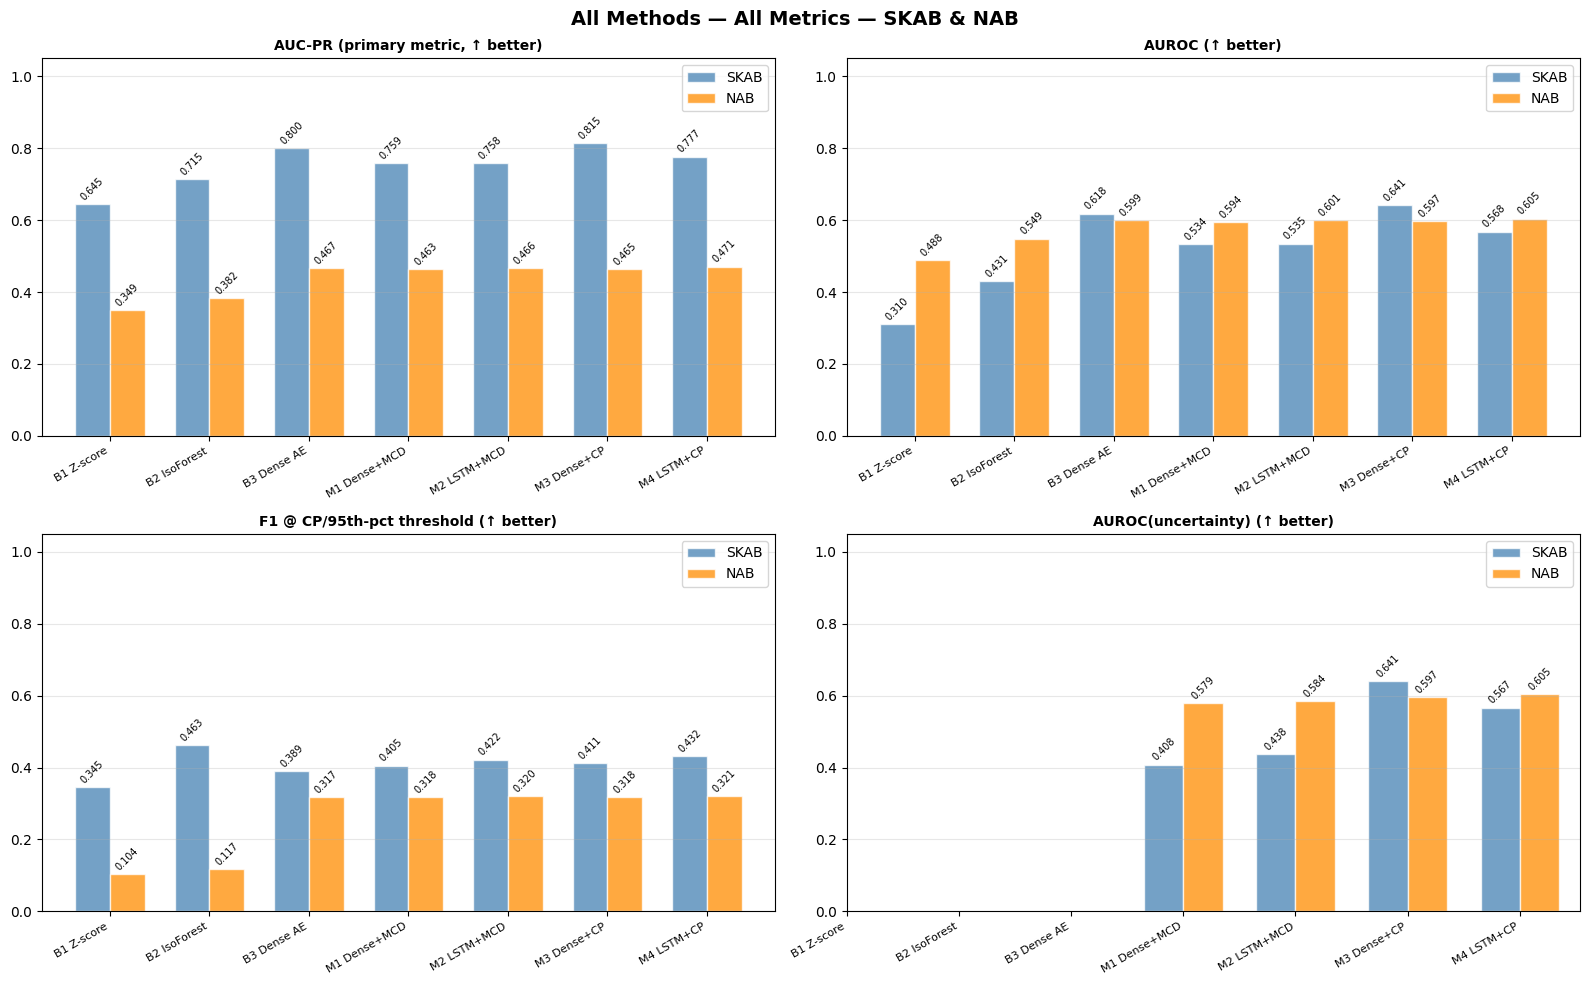

Saved → outputs/final_figures/all_methods_bar_chart.png


In [6]:
METHODS_PLOT = [k for k in METHODS_MAIN if any(results_flat[ds].get(k) for ds in DATASETS)]
METRIC_PAIRS = [
    ("auc_pr",    "AUC-PR (primary metric, ↑ better)"),
    ("auroc",     "AUROC (↑ better)"),
    ("f1",        "F1 @ CP/95th-pct threshold (↑ better)"),
    ("auroc_unc", "AUROC(uncertainty) (↑ better)"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
fig.suptitle("All Methods - All Metrics - SKAB & NAB", fontsize=14, fontweight="bold")

x = np.arange(len(METHODS_PLOT))
width = 0.35
ds_colors = {"SKAB": "steelblue", "NAB": "darkorange"}

for ax_i, (metric_key, title) in enumerate(METRIC_PAIRS):
    ax = axes[ax_i]
    for ds_i, ds in enumerate(DATASETS):
        vals = [results_flat.get(ds, {}).get(k, {}).get(metric_key, float("nan"))
                for k in METHODS_PLOT]
        offset = (ds_i - 0.5) * width
        bars = ax.bar(x + offset, vals, width, label=ds,
                      color=ds_colors[ds], alpha=0.75, edgecolor="white")
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f"{v:.3f}", ha="center", va="bottom", fontsize=7, rotation=45)

    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABELS.get(k, k) for k in METHODS_PLOT],
                       rotation=30, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.axhline(0, color="black", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "all_methods_bar_chart.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


---
## Section 6 - Delta vs B3 Deterministic Baseline

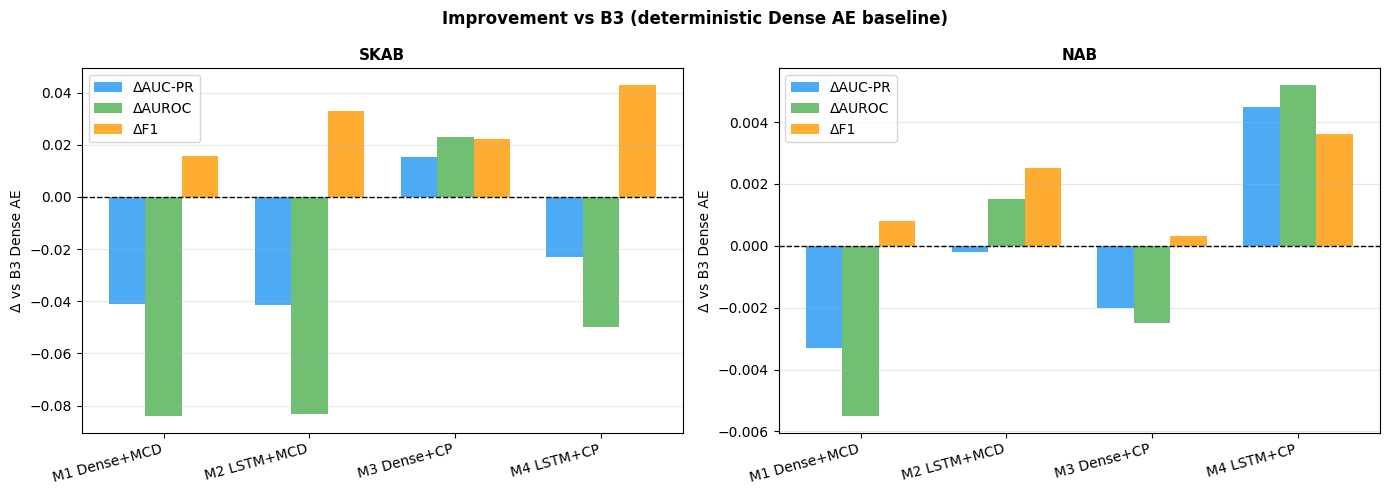

Saved → outputs/final_figures/delta_vs_b3.png

B3 baselines: SKAB auc_pr=0.7998  NAB auc_pr=0.4665


In [7]:
UQ_METHODS = [k for k in ["M1_dense_mcd", "M2_lstm_mcd", "M3_dense_cp", "M4_lstm_cp"]
              if any(results_flat[ds].get(k) for ds in DATASETS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Improvement vs B3 (deterministic Dense AE baseline)",
             fontsize=12, fontweight="bold")

for ax_i, ds in enumerate(DATASETS):
    ax = axes[ax_i]
    b3 = results_flat.get(ds, {}).get("B3_denseae", {})
    b3_ap = b3.get("auc_pr", float("nan"))
    b3_ar = b3.get("auroc",  float("nan"))
    b3_f1 = b3.get("f1",     float("nan"))

    labels, deltas_ap, deltas_ar, deltas_f1 = [], [], [], []
    for key in UQ_METHODS:
        m = results_flat.get(ds, {}).get(key, {})
        if not m:
            continue
        labels.append(METHOD_LABELS.get(key, key))
        deltas_ap.append(m.get("auc_pr", float("nan")) - b3_ap)
        deltas_ar.append(m.get("auroc",  float("nan")) - b3_ar)
        deltas_f1.append(m.get("f1",     float("nan")) - b3_f1)

    x = np.arange(len(labels))
    w = 0.25
    ax.bar(x - w,   deltas_ap, w, label="ΔAUC-PR",  color="#2196F3", alpha=0.8)
    ax.bar(x,       deltas_ar, w, label="ΔAUROC",   color="#4CAF50", alpha=0.8)
    ax.bar(x + w,   deltas_f1, w, label="ΔF1",      color="#FF9800", alpha=0.8)
    ax.axhline(0, color="black", linewidth=1.0, linestyle="--")
    ax.set_title(f"{ds}", fontsize=11, fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.set_ylabel("Δ vs B3 Dense AE")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "delta_vs_b3.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")
print(f"\nB3 baselines: SKAB auc_pr={results_flat.get('SKAB',{}).get('B3_denseae',{}).get('auc_pr','?'):.4f}  "
      f"NAB auc_pr={results_flat.get('NAB',{}).get('B3_denseae',{}).get('auc_pr','?'):.4f}")


---
## Section 7 - Training Curves

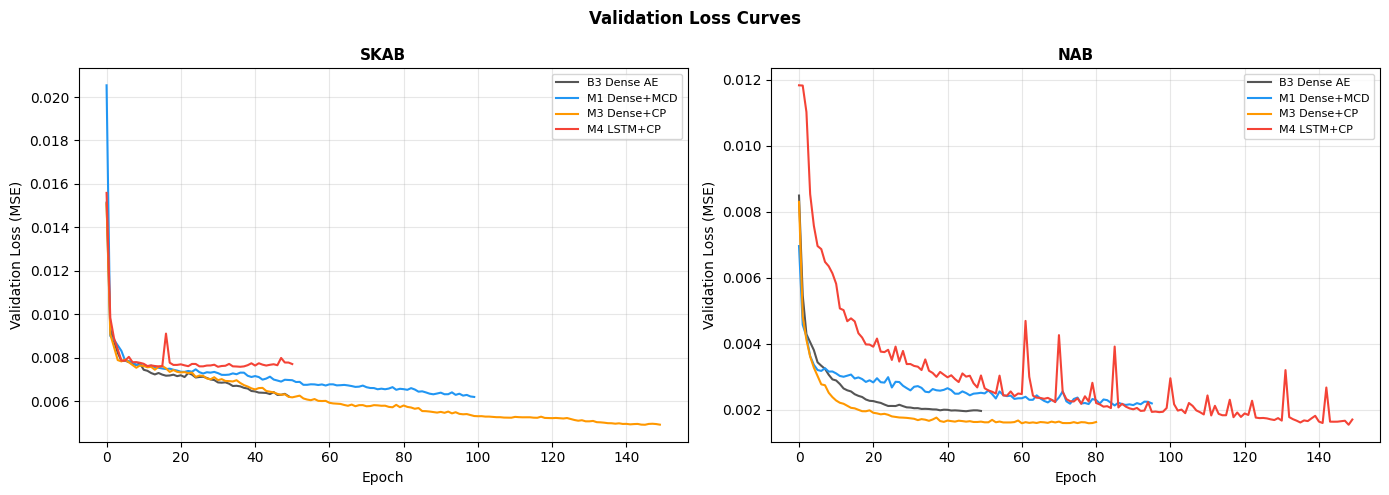

Saved → outputs/final_figures/training_curves.png


In [8]:
CURVE_METHODS = {
    "B3_denseae":   "B3 Dense AE",
    "M1_dense_mcd": "M1 Dense+MCD",
    "M2_lstm_mcd":  "M2 LSTM+MCD",
    "M3_dense_cp":  "M3 Dense+CP",
    "M4_lstm_cp":   "M4 LSTM+CP",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Validation Loss Curves", fontsize=12, fontweight="bold")

for ax_i, ds in enumerate(DATASETS):
    ax = axes[ax_i]
    for key, label in CURVE_METHODS.items():
        entry = results.get(ds, {}).get(key, {})
        val_losses = entry.get("val_losses", [])
        if not val_losses:
            continue
        color = METHOD_COLORS.get(key, "grey")
        ax.plot(val_losses, color=color, label=label, linewidth=1.5)
    ax.set_title(ds, fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Loss (MSE)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


---
## Section 8 - Uncertainty Quality (AUROC(unc))

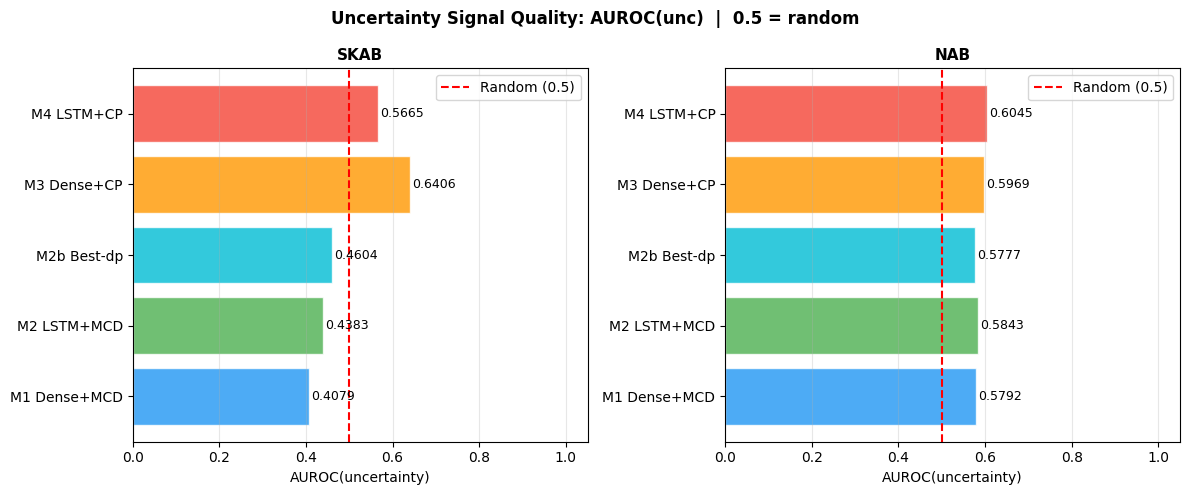

Saved → outputs/final_figures/uncertainty_auroc.png

Interpretation:
  > 0.5: uncertainty std correctly identifies anomalies (good)
  = 0.5: uncertainty is random w.r.t. anomaly labels  (useless)
  < 0.5: uncertainty is INVERTED - anomalies have LOWER uncertainty (bad)

For CP: AUROC(unc) ≈ AUROC since 1-p_value is rank-equivalent to the anomaly score


In [9]:
UNC_METHODS = [k for k in
    ["M1_dense_mcd", "M2_lstm_mcd", "M2b_best", "M3_dense_cp", "M4_lstm_cp"]
    if any(results_flat[ds].get(k) for ds in DATASETS)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Uncertainty Signal Quality: AUROC(unc)  |  0.5 = random",
             fontsize=12, fontweight="bold")

for ax_i, ds in enumerate(DATASETS):
    ax = axes[ax_i]
    labels, vals = [], []
    for key in UNC_METHODS:
        m = results_flat.get(ds, {}).get(key, {})
        v = m.get("auroc_unc", float("nan"))
        if not np.isnan(v):
            labels.append(METHOD_LABELS.get(key, key))
            vals.append(v)

    colors = [METHOD_COLORS.get(k, "grey") for k in UNC_METHODS
              if not np.isnan(results_flat.get(ds, {}).get(k, {}).get("auroc_unc", float("nan")))]
    bars = ax.barh(labels, vals, color=colors, alpha=0.8, edgecolor="white")
    ax.axvline(0.5, color="red", linestyle="--", linewidth=1.5, label="Random (0.5)")
    for bar, v in zip(bars, vals):
        ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
                f"{v:.4f}", va="center", fontsize=9)
    ax.set_title(ds, fontsize=11, fontweight="bold")
    ax.set_xlabel("AUROC(uncertainty)")
    ax.set_xlim(0, 1.05)
    ax.legend()
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "uncertainty_auroc.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")
print()
print("Interpretation:")
print("  > 0.5: uncertainty std correctly identifies anomalies (good)")
print("  = 0.5: uncertainty is random w.r.t. anomaly labels  (useless)")
print("  < 0.5: uncertainty is INVERTED - anomalies have LOWER uncertainty (bad)")
print()
print("For CP: AUROC(unc) ≈ AUROC since 1-p_value is rank-equivalent to the anomaly score")


---
## Section 9 - CP Coverage Validation

In [10]:
print("Conformal Prediction - Formal Coverage Guarantee Validation")
print("=" * 60)
print(f"  Target coverage (1 - α = 1 - {0.05}) = 0.95")
print(f"  Empirical coverage should be ≥ 0.95 on normal test samples")
print()

for ds in DATASETS:
    for key, label in [("M3_dense_cp", "M3 Dense+CP"), ("M4_lstm_cp", "M4 LSTM+CP")]:
        m = results_flat.get(ds, {}).get(key, {})
        cov = m.get("mean_unc", float("nan"))
        if np.isnan(cov):
            continue
        status = "✓ VALID" if cov >= 0.95 else "✗ VIOLATION"
        print(f"  {ds:6} {label:18} coverage={cov:.4f}  [{status}]")


Conformal Prediction - Formal Coverage Guarantee Validation
  Target coverage (1 - α = 1 - 0.05) = 0.95
  Empirical coverage should be ≥ 0.95 on normal test samples

  SKAB   M3 Dense+CP        coverage=0.9409  [✗ VIOLATION]
  SKAB   M4 LSTM+CP         coverage=0.8645  [✗ VIOLATION]
  NAB    M3 Dense+CP        coverage=0.9230  [✗ VIOLATION]
  NAB    M4 LSTM+CP         coverage=0.9237  [✗ VIOLATION]


---
## Section 10 - M2b Dropout Ablation Summary

In [11]:
# Show the dropout sweep results side-by-side with key metrics
for ds, sweep_file in [("SKAB", SWEEP_SKAB_FILE), ("NAB", SWEEP_NAB_FILE)]:
    try:
        with open(sweep_file) as f:
            sweep = json.load(f)
    except FileNotFoundError:
        print(f"  {sweep_file} not found - skipping")
        continue

    if not sweep:
        print(f"  {ds}: no sweep results yet")
        continue

    entries = sorted(sweep.values(), key=lambda e: e["dropout_p"])
    m2_ref  = results_flat.get(ds, {}).get("M2_lstm_mcd", {})

    print(f"\n{ds}  (M2 baseline: AUC-PR={m2_ref.get('auc_pr','?')}  dp=0.05)")
    print(f"  {'dp':>8}  {'AUC-PR':>8}  {'AUROC(unc)':>12}  {'mean_unc':>10}  {'val_loss':>10}")
    print(f"  {'─'*56}")
    for e in entries:
        m  = e["metrics"]
        dp = e["dropout_p"]
        marker = " ←" if abs(dp - 0.001) < 1e-6 else ""
        print(f"  {dp:>8.4f}  {m['auc_pr']:>8.4f}  {m['auroc_unc']:>12.4f}  "
              f"{m.get('mean_unc', float('nan')):>10.2e}  {e['val_loss']:>10.6f}{marker}")
    print(f"  (← best dp by val_loss)")



SKAB  (M2 baseline: AUC-PR=0.7584  dp=0.05)
        dp    AUC-PR    AUROC(unc)    mean_unc    val_loss
  ────────────────────────────────────────────────────────
    0.0010    0.7612        0.5734    5.95e-05    0.007604 ←
    0.0050    0.7619        0.5570    2.12e-04    0.007593
    0.0100    0.7784        0.4604    2.64e-04    0.007184
    0.0200    0.7564        0.4500    9.80e-04    0.007404
    0.0500    0.7582        0.3798    2.12e-04    0.007387
  (← best dp by val_loss)

NAB  (M2 baseline: AUC-PR=0.4663  dp=0.05)
        dp    AUC-PR    AUROC(unc)    mean_unc    val_loss
  ────────────────────────────────────────────────────────
    0.0010    0.4704        0.5723    5.50e-04    0.002025 ←
    0.0050    0.4667        0.5777    2.77e-03    0.001962
    0.0100    0.4692        0.5889    7.59e-03    0.001985
    0.0200    0.4644        0.5841    6.49e-03    0.002236
    0.0500    0.4691        0.5846    1.28e-02    0.002247
  (← best dp by val_loss)


---
## Section 11 - Final Scorecard (Paper Figure)

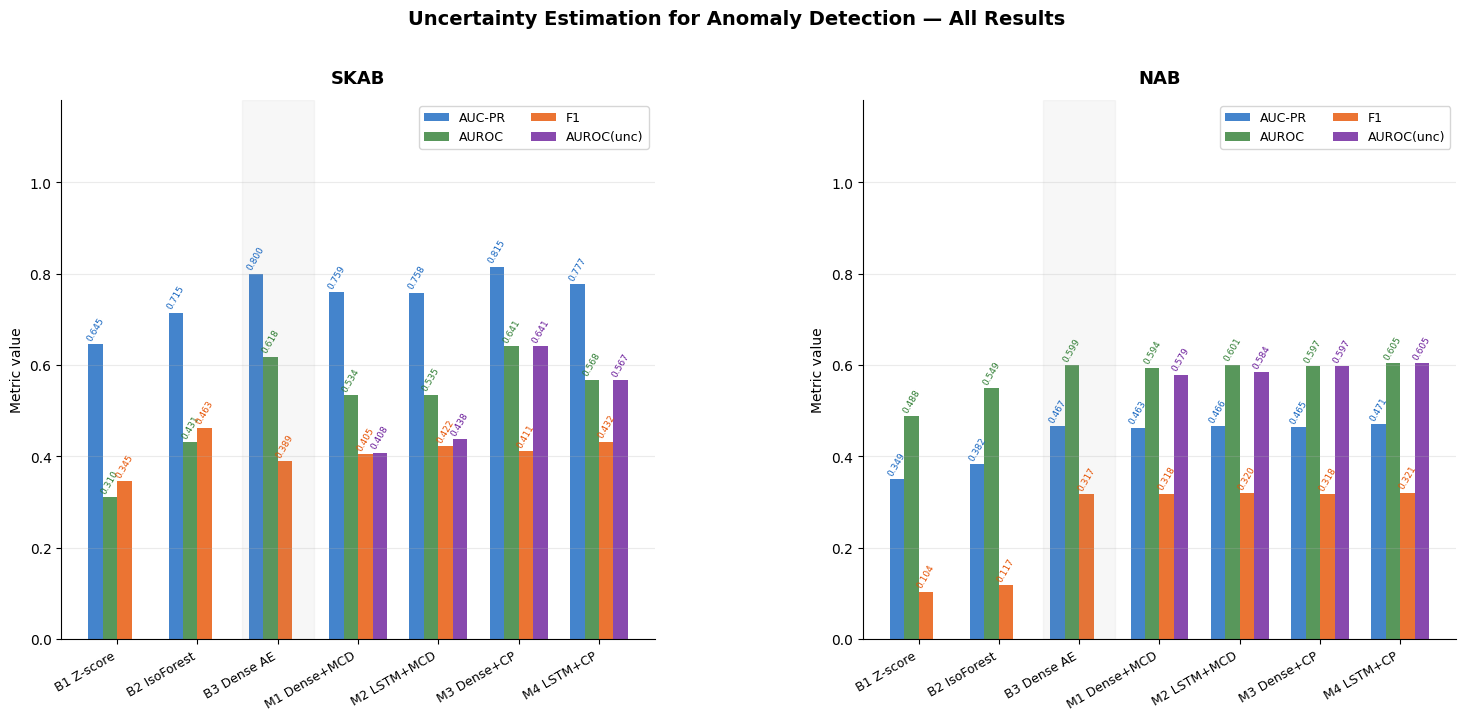

Saved → outputs/final_figures/final_scorecard.png


In [12]:
# Publication-quality summary figure
FIG_METHODS = [k for k in METHODS_MAIN if any(results_flat[ds].get(k) for ds in DATASETS)]
METRIC_LABELS_SHORT = ["AUC-PR", "AUROC", "F1", "AUROC(unc)"]
METRIC_KEYS = ["auc_pr", "auroc", "f1", "auroc_unc"]

fig = plt.figure(figsize=(18, 7))
gs = GridSpec(1, 2, figure=fig, wspace=0.35)

for col_i, ds in enumerate(DATASETS):
    ax = fig.add_subplot(gs[0, col_i])
    n_methods = len(FIG_METHODS)
    n_metrics = len(METRIC_KEYS)
    x = np.arange(n_methods)
    width = 0.18

    metric_colors = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A"]
    for m_i, (mk, ml) in enumerate(zip(METRIC_KEYS, METRIC_LABELS_SHORT)):
        vals = [results_flat.get(ds, {}).get(k, {}).get(mk, float("nan"))
                for k in FIG_METHODS]
        offset = (m_i - (n_metrics - 1) / 2) * width
        bars = ax.bar(x + offset, vals, width, label=ml,
                      color=metric_colors[m_i], alpha=0.8)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.005,
                        f"{v:.3f}", ha="center", va="bottom",
                        fontsize=6.5, rotation=60, color=metric_colors[m_i])

    ax.set_title(f"{ds}", fontsize=13, fontweight="bold", pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABELS.get(k, k) for k in FIG_METHODS],
                       rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1.18)
    ax.set_ylabel("Metric value", fontsize=10)
    ax.legend(loc="upper right", fontsize=9, ncol=2)
    ax.grid(axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # highlight B3 as the "baseline" band
    b3_idx = FIG_METHODS.index("B3_denseae") if "B3_denseae" in FIG_METHODS else -1
    if b3_idx >= 0:
        ax.axvspan(b3_idx - 0.45, b3_idx + 0.45, color="grey", alpha=0.06,
                   label="_nolegend_")

plt.suptitle("Uncertainty Estimation for Anomaly Detection - All Results",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "final_scorecard.png")
plt.savefig(out_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved → {out_path}")


---
## Section 12 - Key Findings

In [13]:
print("=" * 72)
print("  KEY FINDINGS")
print("=" * 72)

for ds in DATASETS:
    rf = results_flat.get(ds, {})
    b3_ap  = rf.get("B3_denseae",  {}).get("auc_pr", float("nan"))
    m1_ap  = rf.get("M1_dense_mcd",{}).get("auc_pr", float("nan"))
    m2_ap  = rf.get("M2_lstm_mcd", {}).get("auc_pr", float("nan"))
    m3_ap  = rf.get("M3_dense_cp", {}).get("auc_pr", float("nan"))
    m4_ap  = rf.get("M4_lstm_cp",  {}).get("auc_pr", float("nan"))
    m2b_ap = rf.get("M2b_best",    {}).get("auc_pr", float("nan"))

    m1_au  = rf.get("M1_dense_mcd",{}).get("auroc_unc", float("nan"))
    m2_au  = rf.get("M2_lstm_mcd", {}).get("auroc_unc", float("nan"))

    all_ap = {k: rf.get(k, {}).get("auc_pr", float("nan"))
              for k in ["B1_zscore","B2_isoforest","B3_denseae",
                        "M1_dense_mcd","M2_lstm_mcd","M3_dense_cp","M4_lstm_cp"]}
    best_key = max((k for k in all_ap if not np.isnan(all_ap[k])),
                   key=lambda k: all_ap[k])

    print(f"\n  {ds}")
    print(f"  {'─'*50}")
    print(f"  Best method (AUC-PR): {METHOD_LABELS.get(best_key, best_key)} = {all_ap[best_key]:.4f}")
    if not np.isnan(b3_ap) and not np.isnan(m1_ap):
        delta = m1_ap - b3_ap
        sign  = "+" if delta >= 0 else ""
        print(f"  MCD vs B3 (Dense):   AUC-PR {sign}{delta:.4f}")
    if not np.isnan(b3_ap) and not np.isnan(m3_ap):
        delta = m3_ap - b3_ap
        sign  = "+" if delta >= 0 else ""
        print(f"  CP  vs B3 (Dense):   AUC-PR {sign}{delta:.4f}")
    if not np.isnan(m1_au):
        qual = "✓ useful" if m1_au > 0.5 else "✗ inverted" if m1_au < 0.5 else "≈ random"
        print(f"  M1 AUROC(unc):       {m1_au:.4f}  - {qual}")
    if not np.isnan(m2_au):
        qual = "✓ useful" if m2_au > 0.5 else "✗ inverted" if m2_au < 0.5 else "≈ random"
        print(f"  M2 AUROC(unc):       {m2_au:.4f}  - {qual}")

print()
print("  Note on Coverage (CP metric):")
print("  For CP models, 'mean_unc' = empirical coverage on normal test samples.")
print("  A value ≥ 0.95 confirms the formal guarantee: FPR ≤ 5% at α=0.05.")
print()
print("  Note on M2b:")
print("  M2b is the dropout ablation on LSTM AE. Lower dropout (0.001) tends to")
print("  improve AUROC(unc) because uncertainty is less noisy - but AUC-PR is similar.")
print("=" * 72)


  KEY FINDINGS

  SKAB
  ──────────────────────────────────────────────────
  Best method (AUC-PR): M3 Dense+CP = 0.8151
  MCD vs B3 (Dense):   AUC-PR -0.0410
  CP  vs B3 (Dense):   AUC-PR +0.0153
  M1 AUROC(unc):       0.4079  - ✗ inverted
  M2 AUROC(unc):       0.4383  - ✗ inverted

  NAB
  ──────────────────────────────────────────────────
  Best method (AUC-PR): M4 LSTM+CP = 0.4710
  MCD vs B3 (Dense):   AUC-PR -0.0033
  CP  vs B3 (Dense):   AUC-PR -0.0020
  M1 AUROC(unc):       0.5792  - ✓ useful
  M2 AUROC(unc):       0.5843  - ✓ useful

  Note on Coverage (CP metric):
  For CP models, 'mean_unc' = empirical coverage on normal test samples.
  A value ≥ 0.95 confirms the formal guarantee: FPR ≤ 5% at α=0.05.

  Note on M2b:
  M2b is the dropout ablation on LSTM AE. Lower dropout (0.001) tends to
  improve AUROC(unc) because uncertainty is less noisy - but AUC-PR is similar.
